# SEC Form 13F ownership-network audit

This notebook audits the quarterly bipartite manager-security networks produced by `scripts/08_build_sec_13f_ownership_networks.py`.

It checks:

1. manager-node, security-node, and quarterly-summary integrity;
2. reconciliation with the Script 07 holdings panel;
3. the construction of the saved node measures; and
4. the size and connectivity of the ownership networks over time.

The notebook reads saved outputs only and does not rebuild the networks.

## 1. Setup and inputs

In [1]:
import sys
from pathlib import Path

import duckdb
import pandas as pd
import pyarrow.parquet as pq


project_root = Path.cwd().resolve()

while not (project_root / "config" / "paths.yaml").is_file():
    if project_root.parent == project_root:
        raise FileNotFoundError("Could not locate the project root.")
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.utils.configuration import get_paths_config


paths = get_paths_config()
holdings_directory = paths.interim / "sec_13f_crsp"
network_directory = paths.interim / "networks" / "ownership"

holdings_path = holdings_directory / "manager_security_holdings.parquet"
totals_path = holdings_directory / "manager_portfolio_totals.parquet"
manager_path = network_directory / "manager_nodes.parquet"
security_path = network_directory / "security_nodes.parquet"
summary_path = network_directory / "network_summary.parquet"

table_paths = {
    "manager_security_holdings": holdings_path,
    "manager_portfolio_totals": totals_path,
    "manager_nodes": manager_path,
    "security_nodes": security_path,
    "network_summary": summary_path,
}

for name, path in table_paths.items():
    if not path.is_file():
        raise FileNotFoundError(f"Required {name} file not found: {path}")

inventory = pd.DataFrame(
    {
        "table": table_paths.keys(),
        "rows": [
            pq.ParquetFile(path).metadata.num_rows
            for path in table_paths.values()
        ],
    }
)

connection = duckdb.connect(database=":memory:")

for name, path in table_paths.items():
    connection.read_parquet(str(path)).create_view(name)

display(inventory.style.format({"rows": "{:,}"}))

,table,rows
0,manager_security_holdings,"40,413,958"
1,manager_portfolio_totals,"251,386"
2,manager_nodes,"251,386"
3,security_nodes,"206,868"
4,network_summary,52


## 2. Output integrity

Node identifiers must be unique within each quarter, and all saved statistics must remain inside their theoretical ranges. Each quarter should have one network-summary row.

In [2]:
manager_checks = connection.execute(
    '''
    SELECT
        COUNT(*) - COUNT(DISTINCT (report_period, CIK))
            AS duplicate_manager_keys,
        COUNT(*) - COUNT(DISTINCT (report_period, manager_index))
            AS duplicate_manager_indices,
        COUNT(*) FILTER (
            WHERE CIK IS NULL OR report_period IS NULL
               OR manager_index IS NULL
        ) AS missing_manager_keys,
        COUNT(*) FILTER (
            WHERE portfolio_value_usd <= 0 OR security_count <= 0
               OR largest_position_weight <= 0
               OR largest_position_weight > 1
               OR portfolio_hhi <= 0 OR portfolio_hhi > 1
        ) AS invalid_manager_statistics
    FROM manager_nodes
    '''
).fetchdf().T.reset_index()
manager_checks.columns = ["check", "violations"]

security_checks = connection.execute(
    '''
    SELECT
        COUNT(*) - COUNT(DISTINCT (report_period, permno))
            AS duplicate_security_keys,
        COUNT(*) - COUNT(DISTINCT (report_period, security_index))
            AS duplicate_security_indices,
        COUNT(*) FILTER (
            WHERE permno IS NULL OR report_period IS NULL
               OR security_index IS NULL
        ) AS missing_security_keys,
        COUNT(*) FILTER (
            WHERE institutional_holder_count <= 0
               OR total_reported_value_usd <= 0
               OR reported_ownership_hhi <= 0
               OR reported_ownership_hhi > 1
               OR top_five_reported_ownership_share <= 0
               OR top_five_reported_ownership_share > 1
               OR mean_owner_portfolio_weight <= 0
               OR maximum_owner_portfolio_weight <= 0
               OR maximum_owner_portfolio_weight > 1
               OR mean_owner_portfolio_weight
                    > maximum_owner_portfolio_weight
        ) AS invalid_security_statistics
    FROM security_nodes
    '''
).fetchdf().T.reset_index()
security_checks.columns = ["check", "violations"]

summary_checks = connection.execute(
    '''
    SELECT
        COUNT(*) - COUNT(DISTINCT report_period)
            AS duplicate_summary_quarters,
        COUNT(*) FILTER (
            WHERE managers <= 0 OR securities <= 0 OR ownership_edges <= 0
        ) AS nonpositive_network_sizes,
        COUNT(*) FILTER (
            WHERE bipartite_density <= 0 OR bipartite_density > 1
               OR connected_components <= 0
               OR largest_component_nodes <= 0
               OR largest_component_nodes > managers + securities
               OR largest_component_share <= 0
               OR largest_component_share > 1
        ) AS invalid_network_statistics,
        COUNT(*) FILTER (
            WHERE abs(
                bipartite_density
                - ownership_edges::DOUBLE / (managers * securities)
            ) > 1e-12
        ) AS density_mismatches,
        COUNT(*) FILTER (
            WHERE abs(
                largest_component_share
                - largest_component_nodes::DOUBLE / (managers + securities)
            ) > 1e-12
        ) AS largest_component_share_mismatches
    FROM network_summary
    '''
).fetchdf().T.reset_index()
summary_checks.columns = ["check", "violations"]

integrity_checks = pd.concat(
    [manager_checks, security_checks, summary_checks],
    ignore_index=True,
)

display(integrity_checks.style.format({"violations": "{:,}"}))
print()
print(f"Total output-integrity violations: {integrity_checks['violations'].sum():,}")

,check,violations
0,duplicate_manager_keys,0
1,duplicate_manager_indices,0
2,missing_manager_keys,0
3,invalid_manager_statistics,0
4,duplicate_security_keys,0
5,duplicate_security_indices,0
6,missing_security_keys,0
7,invalid_security_statistics,0
8,duplicate_summary_quarters,0
9,nonpositive_network_sizes,0



Total output-integrity violations: 0


## 3. Reconciliation with the holdings panel

For every quarter, the numbers of manager nodes, security nodes, and ownership edges should equal the corresponding distinct managers, distinct PERMNOs, and rows in the Script 07 holdings panel. Manager-node portfolio fields should also agree with the saved portfolio totals.

In [3]:
network_reconciliation = connection.execute(
    '''
    WITH holdings_counts AS (
        SELECT
            report_period,
            COUNT(DISTINCT CIK) AS managers,
            COUNT(DISTINCT permno) AS securities,
            COUNT(*) AS ownership_edges
        FROM manager_security_holdings
        GROUP BY report_period
    ),
    node_counts AS (
        SELECT
            COALESCE(m.report_period, s.report_period) AS report_period,
            m.managers,
            s.securities
        FROM (
            SELECT report_period, COUNT(*) AS managers
            FROM manager_nodes GROUP BY report_period
        ) AS m
        FULL JOIN (
            SELECT report_period, COUNT(*) AS securities
            FROM security_nodes GROUP BY report_period
        ) AS s USING (report_period)
    )
    SELECT
        COUNT(*) FILTER (
            WHERE h.report_period IS NULL OR n.report_period IS NULL
               OR x.report_period IS NULL
        ) AS missing_quarters,
        COUNT(*) FILTER (
            WHERE h.managers != n.managers OR h.managers != x.managers
        ) AS manager_count_mismatches,
        COUNT(*) FILTER (
            WHERE h.securities != n.securities
               OR h.securities != x.securities
        ) AS security_count_mismatches,
        COUNT(*) FILTER (
            WHERE h.ownership_edges != x.ownership_edges
        ) AS edge_count_mismatches
    FROM holdings_counts AS h
    FULL JOIN node_counts AS n USING (report_period)
    FULL JOIN network_summary AS x USING (report_period)
    '''
).fetchdf().T.reset_index()
network_reconciliation.columns = ["check", "violations"]

manager_reconciliation = connection.execute(
    '''
    SELECT
        COUNT(*) FILTER (WHERE n.CIK IS NULL) AS totals_without_nodes,
        COUNT(*) FILTER (WHERE t.CIK IS NULL) AS nodes_without_totals,
        COUNT(*) FILTER (
            WHERE n.information_date != t.information_date
               OR n.FILINGMANAGER_NAME != t.FILINGMANAGER_NAME
               OR n.portfolio_value_usd != t.portfolio_value_usd
               OR n.security_count != t.security_count
               OR n.underlying_position_rows != t.underlying_position_rows
        ) AS manager_field_mismatches
    FROM manager_nodes AS n
    FULL JOIN manager_portfolio_totals AS t
        USING (CIK, PERIODOFREPORT, report_period)
    '''
).fetchdf().T.reset_index()
manager_reconciliation.columns = ["check", "violations"]

reconciliation_checks = pd.concat(
    [network_reconciliation, manager_reconciliation],
    ignore_index=True,
)

display(reconciliation_checks.style.format({"violations": "{:,}"}))
print()
print(f"Total reconciliation violations: {reconciliation_checks['violations'].sum():,}")

,check,violations
0,missing_quarters,0
1,manager_count_mismatches,0
2,security_count_mismatches,0
3,edge_count_mismatches,0
4,totals_without_nodes,0
5,nodes_without_totals,0
6,manager_field_mismatches,0



Total reconciliation violations: 0


## 4. Node-measure reconciliation

The main manager and security statistics are recalculated from the holdings and compared with the saved node tables. This validates the measures without reconstructing graph connectivity.

In [4]:
measure_checks = connection.execute(
    '''
    WITH manager_measures AS (
        SELECT
            report_period,
            CIK,
            MAX(portfolio_weight) AS largest_position_weight,
            SUM(portfolio_weight * portfolio_weight) AS portfolio_hhi
        FROM manager_security_holdings
        GROUP BY report_period, CIK
    ),
    manager_check AS (
        SELECT COUNT(*) AS violations
        FROM manager_nodes AS n
        INNER JOIN manager_measures AS m USING (report_period, CIK)
        WHERE abs(n.largest_position_weight - m.largest_position_weight)
                > 1e-10
           OR abs(n.portfolio_hhi - m.portfolio_hhi) > 1e-10
    ),
    security_rows AS (
        SELECT
            *,
            position_value_usd::DOUBLE
                / SUM(position_value_usd) OVER (
                    PARTITION BY report_period, permno
                ) AS reported_holding_share,
            ROW_NUMBER() OVER (
                PARTITION BY report_period, permno
                ORDER BY position_value_usd DESC, CIK
            ) AS holder_rank
        FROM manager_security_holdings
    ),
    security_measures AS (
        SELECT
            report_period,
            permno,
            COUNT(DISTINCT CIK) AS institutional_holder_count,
            SUM(position_value_usd) AS total_reported_value_usd,
            SUM(reported_holding_share * reported_holding_share)
                AS reported_ownership_hhi,
            SUM(reported_holding_share) FILTER (WHERE holder_rank <= 5)
                AS top_five_reported_ownership_share,
            AVG(portfolio_weight) AS mean_owner_portfolio_weight,
            MAX(portfolio_weight) AS maximum_owner_portfolio_weight
        FROM security_rows
        GROUP BY report_period, permno
    ),
    security_check AS (
        SELECT COUNT(*) AS violations
        FROM security_nodes AS n
        INNER JOIN security_measures AS s USING (report_period, permno)
        WHERE n.institutional_holder_count != s.institutional_holder_count
           OR n.total_reported_value_usd != s.total_reported_value_usd
           OR abs(n.reported_ownership_hhi - s.reported_ownership_hhi)
                > 1e-10
           OR abs(
                n.top_five_reported_ownership_share
                - s.top_five_reported_ownership_share
              ) > 1e-10
           OR abs(
                n.mean_owner_portfolio_weight
                - s.mean_owner_portfolio_weight
              ) > 1e-10
           OR abs(
                n.maximum_owner_portfolio_weight
                - s.maximum_owner_portfolio_weight
              ) > 1e-10
    )
    SELECT 'Manager-node measure mismatches' AS check, violations
    FROM manager_check
    UNION ALL
    SELECT 'Security-node measure mismatches', violations
    FROM security_check
    '''
).fetchdf()

display(measure_checks.style.format({"violations": "{:,}"}))
print()
print(f"Total node-measure mismatches: {measure_checks['violations'].sum():,}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,check,violations
0,Manager-node measure mismatches,0
1,Security-node measure mismatches,0



Total node-measure mismatches: 0


## 5. Network structure over time

The quarterly summary describes the number of nodes and edges, network density, connected components, and the share of all nodes contained in the largest connected component.

In [5]:
network_summary = connection.execute(
    "SELECT * FROM network_summary ORDER BY report_period"
).fetchdf()

structure_summary = (
    network_summary[
        [
            "managers",
            "securities",
            "ownership_edges",
            "bipartite_density",
            "connected_components",
            "largest_component_share",
        ]
    ]
    .agg(["min", "median", "max"])
    .T.reset_index(names="measure")
)

display(structure_summary.style.format({
    "min": "{:,.4f}",
    "median": "{:,.4f}",
    "max": "{:,.4f}",
}))

print()
print("First and last quarterly networks")
display(pd.concat([network_summary.head(1), network_summary.tail(1)]))

connection.close()

,measure,min,median,max
0,managers,"2,674.0000","4,537.0000","7,823.0000"
1,securities,"3,752.0000","3,877.0000","4,598.0000"
2,ownership_edges,"478,717.0000","716,855.5000","1,222,964.0000"
3,bipartite_density,0.0316,0.0421,0.0486
4,connected_components,1.0000,1.0000,1.0000
5,largest_component_share,1.0000,1.0000,1.0000



First and last quarterly networks


,PERIODOFREPORT,report_period,information_date,managers,securities,ownership_edges,bipartite_density,connected_components,largest_component_nodes,largest_component_share
0,30-JUN-2013,2013-06-30,2013-08-14,2674,3786,478717,0.047286,1,6460,1.0
51,31-MAR-2026,2026-03-31,2026-05-15,7823,3799,1222964,0.041150,1,11622,1.0


### Network growth: Matplotlib

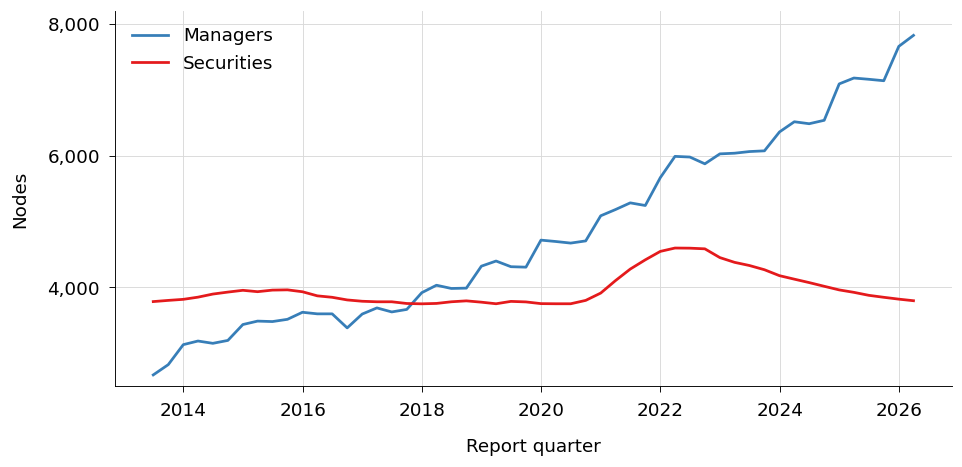

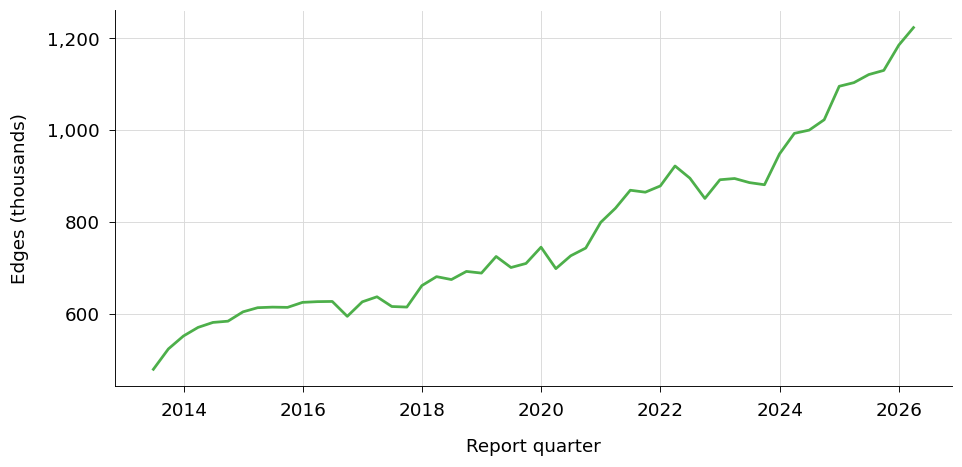

In [6]:
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
import numpy as np
from matplotlib.ticker import PercentFormatter

from src.visualization.style import (
    COLOR_PALETTE,
    SINGLE_PANEL_SIZE,
    apply_matplotlib_layout,
    set_matplotlib_style,
)


set_matplotlib_style()
node_figure, node_axis = plt.subplots(figsize=SINGLE_PANEL_SIZE)

node_axis.set_yticks(np.arange(4000, 8001, 2000))
node_axis.set_ylim(2500, 8200)

node_axis.plot(network_summary["report_period"], network_summary["managers"], label="Managers")
node_axis.plot(network_summary["report_period"], network_summary["securities"], label="Securities")
node_axis.set_ylabel("Nodes")
node_axis.set_xlabel("Report quarter")
node_axis.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
node_axis.legend(frameon=False)

apply_matplotlib_layout(node_figure)
node_figure.savefig(paths.figures / "02_01_network_nodes_matplotlib.pdf")

edge_figure, edge_axis = plt.subplots(figsize=SINGLE_PANEL_SIZE)
edge_axis.plot(
    network_summary["report_period"],
    network_summary["ownership_edges"] / 1_000,
    color=COLOR_PALETTE[2],
)
edge_axis.set_yticks(np.arange(600, 1300, 200))
edge_axis.set_ylabel("Edges (thousands)")
edge_axis.set_xlabel("Report quarter")
edge_axis.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))

apply_matplotlib_layout(edge_figure)
edge_figure.savefig(paths.figures / "02_01_network_edges_matplotlib.pdf")
plt.show()

## 6. Interpretation

- **The saved outputs are internally valid.** Manager and security identifiers are unique within each quarter, all node measures lie inside their theoretical ranges, and every quarter has exactly one network-summary row. All integrity checks return zero violations.
- **The networks reconcile with the holdings panel.** The 251,386 manager nodes and 206,868 security nodes agree with the distinct managers and PERMNOs in the Script 07 holdings. Quarterly manager, security, and edge counts also agree exactly.
- **The node measures are reproducible.** Recalculating portfolio concentration, reported-ownership concentration, holder counts, reported values, and portfolio-weight statistics from the holdings produces zero mismatches with the saved node tables.
- **The graph remains sparse but connected.** Quarterly bipartite density ranges from 3.16% to 4.86%, while every quarterly network has one connected component containing all manager and security nodes. Thus, indirect ownership links connect the complete eligible sample even though only a small fraction of all possible manager-security edges exists.
- **The network expands mainly through managers and holdings.** Managers increase from 2,674 in the first quarter to 7,823 in the last, while securities remain comparatively stable. Quarterly ownership edges increase from 478,717 to 1,222,964.

The Script 08 outputs faithfully represent the Script 07 holdings panel and are suitable for the subsequent manager-similarity analysis.